# Sharma et al. (2024) — DNN Replication

This standalone notebook replicates the DNN experiment on NSL-KDD and UNSW-NB15 using the same preprocessing pipeline as the 1D-CNN replication.

**Setup:** seed 42; 60/15/25 train/validation/test split; 5 classes; 20 epochs; batch size 128; Adam; learning rate 0.001; weight decay 0.0001; hidden layers 64→64→64; ReLU; 5-neuron Softmax; sparse categorical cross-entropy.

**Dropout:** default `0.01`. The paper is internally inconsistent (0.01 vs 0), so change `DROPOUT_RATE` to `0.0` to run the alternative.

In [ ]:
import os, random, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001
EPOCHS = 20
BATCH_SIZE = 128

# Paper inconsistency: one section says 0.01, another says 0.
DROPOUT_RATE = 0.01
NUM_CLASSES = 5

print("TensorFlow:", tf.__version__)
print("Seed:", SEED)

TensorFlow: 2.20.0
Seed: 42


# 2. Load & preprocess NSL-KDD

Expected files:

```text
/content/NSL-KDD/KDDTrain+
/content/NSL-KDD/KDDTest+
```

The files are combined, mapped to five classes, split 60/15/25, categorical features are ordinal-encoded, numerical features are cleaned, and MinMaxScaler is fitted only on the training set.

In [ ]:
# ============================================================
# 2. Load NSL-KDD
# ============================================================

# Your files are uploaded directly into /content/
# with .txt extensions.

NSL_TRAIN_PATH = "/content/KDDTrain+.txt"
NSL_TEST_PATH = "/content/KDDTest+.txt"

print("NSL-KDD training file:", NSL_TRAIN_PATH)
print("NSL-KDD testing file :", NSL_TEST_PATH)

# ------------------------------------------------------------
# Standard NSL-KDD column names
# ------------------------------------------------------------

NSL_COLUMNS = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "attack",
    "difficulty"
]

# ------------------------------------------------------------
# NSL-KDD attack → 5-class mapping
# ------------------------------------------------------------

NSL_ATTACK_MAP = {
    # Normal
    "normal": "Normal",

    # DoS
    "back": "DoS",
    "land": "DoS",
    "neptune": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",
    "mailbomb": "DoS",
    "apache2": "DoS",
    "processtable": "DoS",
    "udpstorm": "DoS",

    # Probe
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "satan": "Probe",
    "mscan": "Probe",
    "saint": "Probe",

    # R2L
    "ftp_write": "R2L",
    "guess_passwd": "R2L",
    "imap": "R2L",
    "multihop": "R2L",
    "phf": "R2L",
    "spy": "R2L",
    "warezclient": "R2L",
    "warezmaster": "R2L",
    "sendmail": "R2L",
    "named": "R2L",
    "snmpgetattack": "R2L",
    "snmpguess": "R2L",
    "xlock": "R2L",
    "xsnoop": "R2L",

    # U2R
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "perl": "U2R",
    "rootkit": "U2R",
    "httptunnel": "U2R",
    "ps": "U2R",
    "sqlattack": "U2R",
    "xterm": "U2R"
}

# ------------------------------------------------------------
# Load NSL-KDD files
# ------------------------------------------------------------

nsl_train = pd.read_csv(
    NSL_TRAIN_PATH,
    header=None,
    names=NSL_COLUMNS
)

nsl_test = pd.read_csv(
    NSL_TEST_PATH,
    header=None,
    names=NSL_COLUMNS
)

# Combine the two files
nsl = pd.concat(
    [nsl_train, nsl_test],
    ignore_index=True
)

print("\nNSL-KDD training shape:", nsl_train.shape)
print("NSL-KDD testing shape :", nsl_test.shape)
print("Combined shape        :", nsl.shape)

print("\nFirst 5 rows:")
display(nsl.head())

NSL-KDD training file: /content/KDDTrain+.txt
NSL-KDD testing file : /content/KDDTest+.txt

NSL-KDD training shape: (41474, 43)
NSL-KDD testing shape : (22544, 43)
Combined shape        : (64018, 43)

First 5 rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20.0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15.0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19.0
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21.0
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21.0


In [ ]:
nsl["attack"] = nsl["attack"].astype(str).str.strip().str.lower().str.rstrip(".")
nsl["target"] = nsl["attack"].map(NSL_ATTACK_MAP)
nsl = nsl.dropna(subset=["target"]).reset_index(drop=True)

X_nsl = nsl.drop(columns=["target","attack","difficulty"])
y_nsl_text = nsl["target"].copy()
X_nsl = X_nsl.drop(columns=NSL_DROP_COLUMNS, errors="ignore")

X_train_nsl, X_temp_nsl, y_train_nsl_text, y_temp_nsl_text = train_test_split(
    X_nsl, y_nsl_text, test_size=0.40, random_state=SEED, stratify=y_nsl_text
)
X_val_nsl, X_test_nsl, y_val_nsl_text, y_test_nsl_text = train_test_split(
    X_temp_nsl, y_temp_nsl_text, test_size=0.625, random_state=SEED, stratify=y_temp_nsl_text
)

nsl_label_encoder = LabelEncoder()
y_train_nsl = nsl_label_encoder.fit_transform(y_train_nsl_text)
y_val_nsl = nsl_label_encoder.transform(y_val_nsl_text)
y_test_nsl = nsl_label_encoder.transform(y_test_nsl_text)

categorical_nsl = X_train_nsl.select_dtypes(include=["object","category"]).columns.tolist()
numerical_nsl = [c for c in X_train_nsl.columns if c not in categorical_nsl]

nsl_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_nsl_cat = nsl_encoder.fit_transform(X_train_nsl[categorical_nsl])
X_val_nsl_cat = nsl_encoder.transform(X_val_nsl[categorical_nsl])
X_test_nsl_cat = nsl_encoder.transform(X_test_nsl[categorical_nsl])

def clean_numeric(df, columns):
    return df[columns].apply(pd.to_numeric, errors="coerce").replace([np.inf,-np.inf], np.nan).fillna(0)

X_train_nsl_num = clean_numeric(X_train_nsl, numerical_nsl)
X_val_nsl_num = clean_numeric(X_val_nsl, numerical_nsl)
X_test_nsl_num = clean_numeric(X_test_nsl, numerical_nsl)

X_train_nsl_processed = np.hstack([X_train_nsl_num.values, X_train_nsl_cat])
X_val_nsl_processed = np.hstack([X_val_nsl_num.values, X_val_nsl_cat])
X_test_nsl_processed = np.hstack([X_test_nsl_num.values, X_test_nsl_cat])

nsl_scaler = MinMaxScaler()
X_train_nsl_processed = nsl_scaler.fit_transform(X_train_nsl_processed)
X_val_nsl_processed = nsl_scaler.transform(X_val_nsl_processed)
X_test_nsl_processed = nsl_scaler.transform(X_test_nsl_processed)

print("NSL-KDD:", X_train_nsl_processed.shape, X_val_nsl_processed.shape, X_test_nsl_processed.shape)
print("Classes:", nsl_label_encoder.classes_)

NSL-KDD: (38409, 35) (9602, 35) (16004, 35)
Classes: ['DoS' 'Normal' 'Probe' 'R2L' 'U2R']


# 3. Load & preprocess UNSW-NB15

Expected files:

```text
/content/UNSW-NB15/UNSW_NB15_training-set
/content/UNSW-NB15/UNSW_NB15_testing-set
```

Only these two labeled files are needed by this notebook.

In [ ]:
# ============================================================
# 3. Load & preprocess UNSW-NB15
# ============================================================

# Your UNSW-NB15 files are directly inside /content/
# and have .csv extensions.

UNSW_TRAIN_PATH = "/content/UNSW_NB15_training-set.csv"
UNSW_TEST_PATH = "/content/UNSW_NB15_testing-set.csv"

print("UNSW-NB15 training file:", UNSW_TRAIN_PATH)
print("UNSW-NB15 testing file :", UNSW_TEST_PATH)

# ------------------------------------------------------------
# Load UNSW-NB15 files
# ------------------------------------------------------------

unsw_train = pd.read_csv(
    UNSW_TRAIN_PATH
)

unsw_test = pd.read_csv(
    UNSW_TEST_PATH
)

# Combine training and testing files
unsw = pd.concat(
    [unsw_train, unsw_test],
    ignore_index=True
)

print("\nUNSW-NB15 training shape:", unsw_train.shape)
print("UNSW-NB15 testing shape :", unsw_test.shape)
print("Combined shape          :", unsw.shape)

print("\nUNSW-NB15 columns:")
print(unsw.columns.tolist())

print("\nFirst 5 rows:")
display(unsw.head())

UNSW-NB15 training file: /content/UNSW_NB15_training-set.csv
UNSW-NB15 testing file : /content/UNSW_NB15_testing-set.csv

UNSW-NB15 training shape: (24800, 45)
UNSW-NB15 testing shape : (20081, 45)
Combined shape          : (44881, 45)

UNSW-NB15 columns:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

First 5 rows:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1.0,2.0,0.0,0.0,0.0,1.0,2.0,0.0,Normal,0.0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1.0,2.0,0.0,0.0,0.0,1.0,2.0,0.0,Normal,0.0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1.0,3.0,0.0,0.0,0.0,1.0,3.0,0.0,Normal,0.0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1.0,3.0,0.0,0.0,0.0,2.0,3.0,0.0,Normal,0.0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1.0,3.0,0.0,0.0,0.0,2.0,3.0,0.0,Normal,0.0


In [ ]:
UNSW_CLASSES = ["Normal","Generic","Exploits","DoS","Fuzzers"]

unsw["attack_cat"] = unsw["attack_cat"].astype(str).str.strip()
unsw = unsw[unsw["attack_cat"].isin(UNSW_CLASSES)].copy()

parts = []
for class_name in UNSW_CLASSES:
    class_df = unsw[unsw["attack_cat"] == class_name].copy()
    if len(class_df) > 50000:
        class_df = class_df.sample(n=50000, random_state=SEED)
    parts.append(class_df)

unsw = pd.concat(parts, ignore_index=True)
unsw = unsw.sample(frac=1, random_state=SEED).reset_index(drop=True)

UNSW_DROP_COLUMNS = ["ct_src_dport_ltm","loss","dwin","ct_ftp_cmd","label","ct_srv_dst"]

X_unsw = unsw.drop(columns=["attack_cat"], errors="ignore")
y_unsw_text = unsw["attack_cat"].copy()
X_unsw = X_unsw.drop(columns=UNSW_DROP_COLUMNS, errors="ignore")
X_unsw = X_unsw.drop(columns=["id"], errors="ignore")

X_train_unsw, X_temp_unsw, y_train_unsw_text, y_temp_unsw_text = train_test_split(
    X_unsw, y_unsw_text, test_size=0.40, random_state=SEED, stratify=y_unsw_text
)
X_val_unsw, X_test_unsw, y_val_unsw_text, y_test_unsw_text = train_test_split(
    X_temp_unsw, y_temp_unsw_text, test_size=0.625, random_state=SEED, stratify=y_temp_unsw_text
)

unsw_label_encoder = LabelEncoder()
y_train_unsw = unsw_label_encoder.fit_transform(y_train_unsw_text)
y_val_unsw = unsw_label_encoder.transform(y_val_unsw_text)
y_test_unsw = unsw_label_encoder.transform(y_test_unsw_text)

categorical_unsw = X_train_unsw.select_dtypes(include=["object","category"]).columns.tolist()
numerical_unsw = [c for c in X_train_unsw.columns if c not in categorical_unsw]

unsw_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_unsw_cat = unsw_encoder.fit_transform(X_train_unsw[categorical_unsw])
X_val_unsw_cat = unsw_encoder.transform(X_val_unsw[categorical_unsw])
X_test_unsw_cat = unsw_encoder.transform(X_test_unsw[categorical_unsw])

X_train_unsw_num = clean_numeric(X_train_unsw, numerical_unsw)
X_val_unsw_num = clean_numeric(X_val_unsw, numerical_unsw)
X_test_unsw_num = clean_numeric(X_test_unsw, numerical_unsw)

X_train_unsw_processed = np.hstack([X_train_unsw_num.values, X_train_unsw_cat])
X_val_unsw_processed = np.hstack([X_val_unsw_num.values, X_val_unsw_cat])
X_test_unsw_processed = np.hstack([X_test_unsw_num.values, X_test_unsw_cat])

unsw_scaler = MinMaxScaler()
X_train_unsw_processed = unsw_scaler.fit_transform(X_train_unsw_processed)
X_val_unsw_processed = unsw_scaler.transform(X_val_unsw_processed)
X_test_unsw_processed = unsw_scaler.transform(X_test_unsw_processed)

print("UNSW-NB15:", X_train_unsw_processed.shape, X_val_unsw_processed.shape, X_test_unsw_processed.shape)
print("Classes:", unsw_label_encoder.classes_)

UNSW-NB15: (25660, 38) (6415, 38) (10692, 38)
Classes: ['DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal']


# 4. DNN model definition

Architecture: Dense(64) → Dense(64) → Dense(64) → Dense(5, Softmax), with ReLU hidden activations and editable dropout.

In [ ]:
def build_dnn(input_dim, dropout_rate=DROPOUT_RATE):
    model = Sequential([
        Dense(64, activation="relu", input_shape=(input_dim,)),
        Dropout(dropout_rate),
        Dense(64, activation="relu"),
        Dropout(dropout_rate),
        Dense(64, activation="relu"),
        Dropout(dropout_rate),
        Dense(NUM_CLASSES, activation="softmax")
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

dnn_nsl = build_dnn(X_train_nsl_processed.shape[1])
dnn_unsw = build_dnn(X_train_unsw_processed.shape[1])

dnn_nsl.summary()
dnn_unsw.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,949 (42.77 KB)

 Trainable params: 10,949 (42.77 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,141 (43.52 KB)

 Trainable params: 11,141 (43.52 KB)

 Non-trainable params: 0 (0.00 B)

# 5. Train on NSL-KDD

In [ ]:
history_nsl = dnn_nsl.fit(
    X_train_nsl_processed, y_train_nsl,
    validation_data=(X_val_nsl_processed, y_val_nsl),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8685 - loss: 0.4119 - val_accuracy: 0.9305 - val_loss: 0.1942
Epoch 2/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9345 - loss: 0.1862 - val_accuracy: 0.9442 - val_loss: 0.1490
Epoch 3/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9458 - loss: 0.1500 - val_accuracy: 0.9591 - val_loss: 0.1273
Epoch 4/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9547 - loss: 0.1279 - val_accuracy: 0.9646 - val_loss: 0.1088
Epoch 5/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9604 - loss: 0.1126 - val_accuracy: 0.9679 - val_loss: 0.1007
Epoch 6/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9654 - loss: 0.0990 - val_accuracy: 0.9698 - val_loss: 0.0917
Epoch 7/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9690 - loss: 0.0895 - val_accuracy: 0.9724 - val_loss: 0.0832
Epoch 8/20
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9708 - loss: 0.0837 - val_accuracy: 0

# 6. Train on UNSW-NB15

In [ ]:
history_unsw = dnn_unsw.fit(
    X_train_unsw_processed, y_train_unsw,
    validation_data=(X_val_unsw_processed, y_val_unsw),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8419 - loss: 0.4767 - val_accuracy: 0.8901 - val_loss: 0.2541
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8973 - loss: 0.2319 - val_accuracy: 0.8970 - val_loss: 0.2258
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9014 - loss: 0.2147 - val_accuracy: 0.8998 - val_loss: 0.2191
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9035 - loss: 0.2086 - val_accuracy: 0.9004 - val_loss: 0.2176
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9043 - loss: 0.2050 - val_accuracy: 0.9012 - val_loss: 0.2149
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9069 - loss: 0.2011 - val_accuracy: 0.9037 - val_loss: 0.2118
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9065 - loss: 0.1991 - val_accuracy: 0.9041 - val_loss: 0.2127
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9075 - loss: 0.1972 - val_accuracy: 0

# 7. Evaluation

In [ ]:
def evaluate_model(model, X_test, y_test, label_encoder, dataset_name):
    probabilities = model.predict(X_test, verbose=0)
    y_pred = np.argmax(probabilities, axis=1)

    metrics = {
        "dataset": dataset_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    }

    cm = confusion_matrix(y_test, y_pred)

    print("=" * 70)
    print(dataset_name)
    print("=" * 70)
    for k, v in metrics.items():
        if k != "dataset":
            print(f"{k:22s}: {v:.6f}")

    print("\nClassification report:")
    print(classification_report(
        y_test, y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    ))
    return metrics, cm, y_pred

nsl_metrics, cm_nsl, y_pred_nsl = evaluate_model(
    dnn_nsl, X_test_nsl_processed, y_test_nsl, nsl_label_encoder, "NSL-KDD"
)
unsw_metrics, cm_unsw, y_pred_unsw = evaluate_model(
    dnn_unsw, X_test_unsw_processed, y_test_unsw, unsw_label_encoder, "UNSW-NB15"
)

NSL-KDD
accuracy              : 0.976506
precision_macro       : 0.911678
precision_weighted    : 0.977157
recall_macro          : 0.912633
recall_weighted       : 0.976506
f1_macro              : 0.911299
f1_weighted           : 0.976664

Classification report:
              precision    recall  f1-score   support

         DoS       0.99      1.00      1.00      5669
      Normal       0.99      0.97      0.98      7939
       Probe       0.93      0.99      0.96      1565
         R2L       0.85      0.91      0.88       777
         U2R       0.79      0.70      0.75        54

    accuracy                           0.98     16004
   macro avg       0.91      0.91      0.91     16004
weighted avg       0.98      0.98      0.98     16004

UNSW-NB15
accuracy              : 0.908623
precision_macro       : 0.745989
precision_weighted    : 0.911518
recall_macro          : 0.758622
recall_weighted       : 0.908623
f1_macro              : 0.752017
f1_weighted           : 0.909999

Classi

# 8. Training/validation curves and confusion matrices

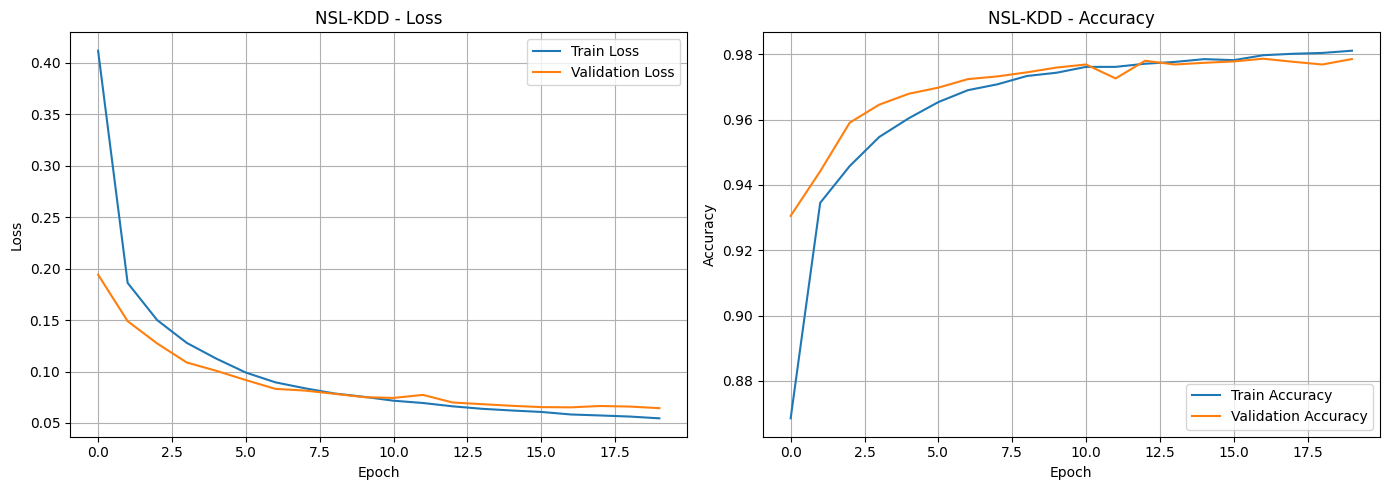

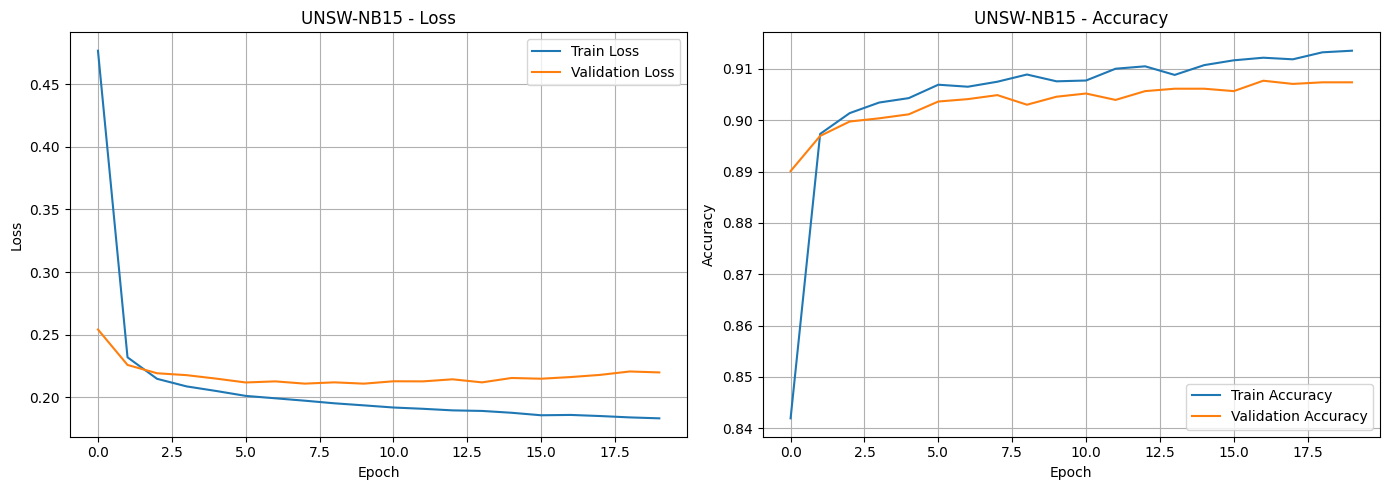

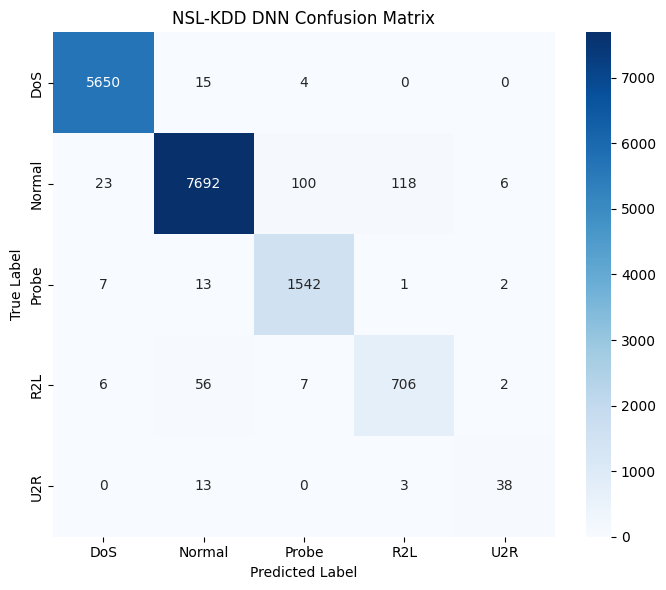

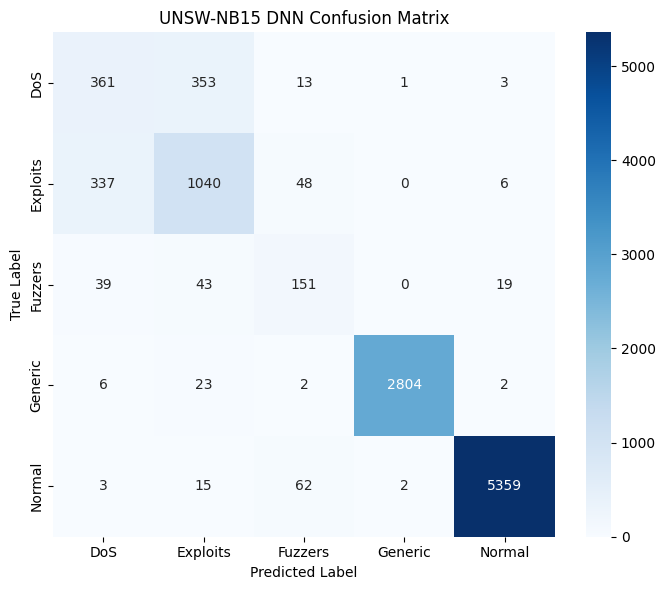

In [ ]:
def plot_training_curves(history, dataset_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_title(f"{dataset_name} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history["accuracy"], label="Train Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
    axes[1].set_title(f"{dataset_name} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def plot_cm(cm, encoder, title):
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=encoder.classes_,
        yticklabels=encoder.classes_
    )
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

plot_training_curves(history_nsl, "NSL-KDD")
plot_training_curves(history_unsw, "UNSW-NB15")
plot_cm(cm_nsl, nsl_label_encoder, "NSL-KDD DNN Confusion Matrix")
plot_cm(cm_unsw, unsw_label_encoder, "UNSW-NB15 DNN Confusion Matrix")

# 9. Save outputs & create downloadable ZIP

Creates exactly:

```text
outputs/
├── metrics.csv
├── confusion_matrix_nsl.png
├── confusion_matrix_unsw.png
├── training_curves_nsl.png
└── training_curves_unsw.png
```

and downloads `dnn_results.zip` in Google Colab.

In [ ]:
OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

metrics_df = pd.DataFrame([nsl_metrics, unsw_metrics])[
    ["dataset","accuracy","precision_macro","precision_weighted",
     "recall_macro","recall_weighted","f1_macro","f1_weighted"]
]
metrics_df.to_csv(os.path.join(OUTPUT_DIR, "metrics.csv"), index=False)

def save_cm(cm, encoder, title, path):
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=encoder.classes_,
        yticklabels=encoder.classes_
    )
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()

save_cm(
    cm_nsl, nsl_label_encoder, "NSL-KDD DNN Confusion Matrix",
    os.path.join(OUTPUT_DIR, "confusion_matrix_nsl.png")
)
save_cm(
    cm_unsw, unsw_label_encoder, "UNSW-NB15 DNN Confusion Matrix",
    os.path.join(OUTPUT_DIR, "confusion_matrix_unsw.png")
)

def save_curves(history, dataset_name, path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_title(f"{dataset_name} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history["accuracy"], label="Train Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
    axes[1].set_title(f"{dataset_name} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()

save_curves(
    history_nsl, "NSL-KDD",
    os.path.join(OUTPUT_DIR, "training_curves_nsl.png")
)
save_curves(
    history_unsw, "UNSW-NB15",
    os.path.join(OUTPUT_DIR, "training_curves_unsw.png")
)

required_files = [
    "metrics.csv",
    "confusion_matrix_nsl.png",
    "confusion_matrix_unsw.png",
    "training_curves_nsl.png",
    "training_curves_unsw.png"
]

print(metrics_df)
print("\nOutput files:")
for name in required_files:
    print(name, "->", os.path.exists(os.path.join(OUTPUT_DIR, name)))

     dataset  accuracy  precision_macro  precision_weighted  recall_macro  \
0    NSL-KDD  0.976506         0.911678            0.977157      0.912633   
1  UNSW-NB15  0.908623         0.745989            0.911518      0.758622   

   recall_weighted  f1_macro  f1_weighted  
0         0.976506  0.911299     0.976664  
1         0.908623  0.752017     0.909999  

Output files:
metrics.csv -> True
confusion_matrix_nsl.png -> True
confusion_matrix_unsw.png -> True
training_curves_nsl.png -> True
training_curves_unsw.png -> True


In [ ]:
ZIP_PATH = "/content/dnn_results.zip"

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files_in_dir in os.walk(OUTPUT_DIR):
        for filename in files_in_dir:
            filepath = os.path.join(root, filename)
            arcname = os.path.relpath(filepath, OUTPUT_DIR)
            zipf.write(filepath, arcname=arcname)

print("Created:", ZIP_PATH)

try:
    from google.colab import files
    files.download(ZIP_PATH)
except ImportError:
    print("Google Colab not detected; ZIP saved locally at:", ZIP_PATH)

Created: /content/dnn_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 10. Optional SHAP explainability

In [ ]:
# Optional: install SHAP
!pip install -q shap

In [ ]:
# Optional: Kernel SHAP on a small NSL-KDD sample
import shap

BACKGROUND_SIZE = 50
EXPLAIN_SIZE = 10

background = X_train_nsl_processed[:BACKGROUND_SIZE]
explain_samples = X_test_nsl_processed[:EXPLAIN_SIZE]

def dnn_predict_nsl(x):
    return dnn_nsl.predict(x, verbose=0)

explainer_nsl = shap.KernelExplainer(dnn_predict_nsl, background)
shap_values_nsl = explainer_nsl.shap_values(explain_samples)

print("SHAP computation completed.")

  0%|          | 0/10 [00:00<?, ?it/s]

SHAP computation completed.


/tmp/ipykernel_2619/2603760837.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_nsl, explain_samples, show=True)
/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.13/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.13/dist-packages/shap/plots/_

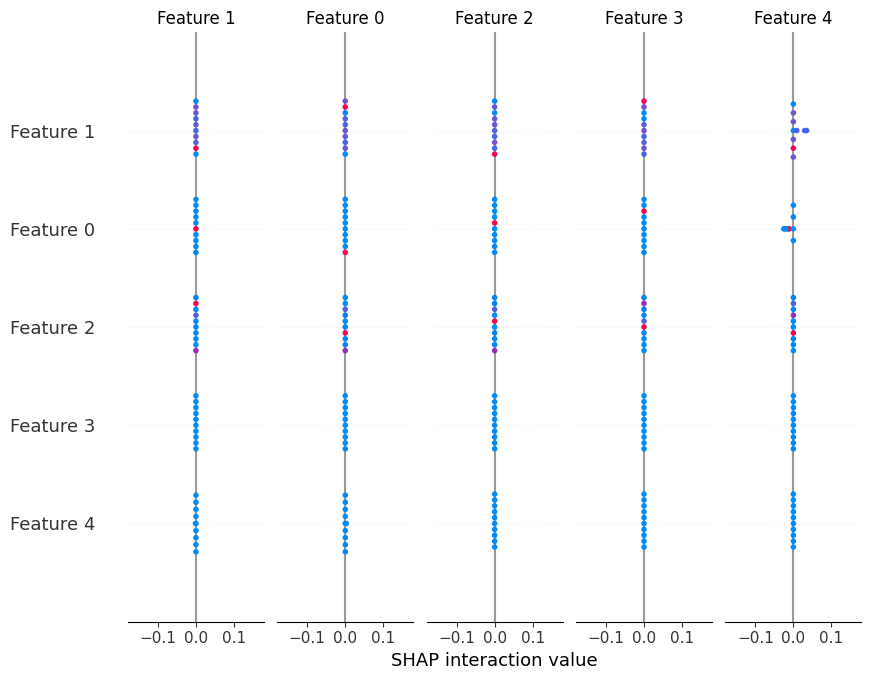

In [ ]:
# Optional SHAP summary plot
shap.summary_plot(shap_values_nsl, explain_samples, show=True)